In [1]:
!pip install networkx python-louvain -q

In [2]:
import pandas as pd
import numpy as np

import networkx as nx

import matplotlib.pyplot as plt

import community.community_louvain as community_louvain

import os

plt.style.use("ggplot")

print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path="/content/Dataset_B_Country_Features (2).csv"

df=pd.read_csv(file_path)

print(df.shape)

display(df.head())

(215, 22)


,Continent,Country,Date of First Case(s),Last Visited Country(s) of Confirmed Case(s),Confirmed Case(s) at First Day,Age of First Case(s),Date of First Death(s),Age of First Death(s),Days_Since_Global_First_Case,First_Case_Month,...,First_Case_DayOfYear,First_Case_Quarter,First_Case_Year,Has_Travel_Origin,Origin_Count,Multiple_Origins,Origin,Death_Recorded,Days_To_First_Death,Multiple_First_Day_Cases
0,Asia,China,2019-11-17,Starting Country,1,55,NaN,NaN,0,11,...,321,4,2019,True,1,False,Starting Country,False,NaN,False
1,Europe,France,2019-12-27,NaN,1,43,2020-02-15,80,40,12,...,361,4,2019,False,0,False,NaN,True,50.0,False
2,Asia,Nepal,2020-01-13,China,1,32,2020-05-16,29,57,1,...,13,1,2020,True,1,False,China,True,124.0,False
3,Asia,Thailand,2020-01-13,China,1,61,2020-03-01,35,57,1,...,13,1,2020,True,1,False,China,True,48.0,False
4,Asia,Japan,2020-01-16,China,1,30+,2020-02-13,80+,60,1,...,16,1,2020,True,1,False,China,True,28.0,False


In [5]:
print("="*60)

print("Columns")

print("="*60)

for col in df.columns:

    print(col)

Columns
Continent
Country
Date of First Case(s)
Last Visited Country(s) of Confirmed Case(s)
Confirmed Case(s) at First Day
Age of First Case(s)
Date of First Death(s)
Age of First Death(s)
Days_Since_Global_First_Case
First_Case_Month
First_Case_Month_Name
First_Case_Week
First_Case_DayOfYear
First_Case_Quarter
First_Case_Year
Has_Travel_Origin
Origin_Count
Multiple_Origins
Origin
Death_Recorded
Days_To_First_Death
Multiple_First_Day_Cases


In [6]:
possible_origin_columns = [

    "Primary_Origin",

    "Origin",

    "Origin_Country",

    "Travel_Origin",

    "Last Visited Country",

    "Last_Visited_Country"

]

origin_column = None

for col in possible_origin_columns:

    if col in df.columns:

        origin_column = col

        break

if origin_column is None:

    raise ValueError(

        "No origin column found.\n"

        "Please check the dataset."

    )

print("Origin Column Found")

print(origin_column)

Origin Column Found
Origin


In [7]:
graph_df = df[

    [origin_column,

     "Country"]

].copy()

graph_df.columns = [

    "Origin",

    "Destination"

]

graph_df = graph_df.dropna()

graph_df = graph_df[
    graph_df["Origin"]!="Unknown"
]

display(graph_df.head())

,Origin,Destination
0,Starting Country,China
2,China,Nepal
3,China,Thailand
4,China,Japan
5,China,South Korea


In [8]:
G = nx.DiGraph()

for _, row in graph_df.iterrows():

    origin = row["Origin"]

    destination = row["Destination"]

    if G.has_edge(origin,destination):

        G[origin][destination]["weight"] += 1

    else:

        G.add_edge(

            origin,

            destination,

            weight=1

        )

In [9]:
print("="*60)

print("NETWORK SUMMARY")

print("="*60)

print("Nodes")

print(G.number_of_nodes())

print()

print("Edges")

print(G.number_of_edges())

print()

print("Density")

print(nx.density(G))

NETWORK SUMMARY
Nodes
178

Edges
202

Density
0.006411477178950041


In [10]:
output_folder="/content/drive/MyDrive/COVID/AdvancedNetwork"

tables_folder=os.path.join(

    output_folder,

    "Tables"

)

figures_folder=os.path.join(

    output_folder,

    "Figures"

)

os.makedirs(

    tables_folder,

    exist_ok=True

)

os.makedirs(

    figures_folder,

    exist_ok=True

)

edge_list=[]

for u,v,d in G.edges(data=True):

    edge_list.append([

        u,

        v,

        d["weight"]

    ])

edges_df=pd.DataFrame(

    edge_list,

    columns=[

        "Origin",

        "Destination",

        "Weight"

    ]

)

display(edges_df.head())

edges_df.to_csv(

    os.path.join(

        tables_folder,

        "NetworkEdges.csv"

    ),

    index=False

)

,Origin,Destination,Weight
0,Starting Country,China,1
1,China,Nepal,1
2,China,Thailand,1
3,China,Japan,1
4,China,South Korea,1


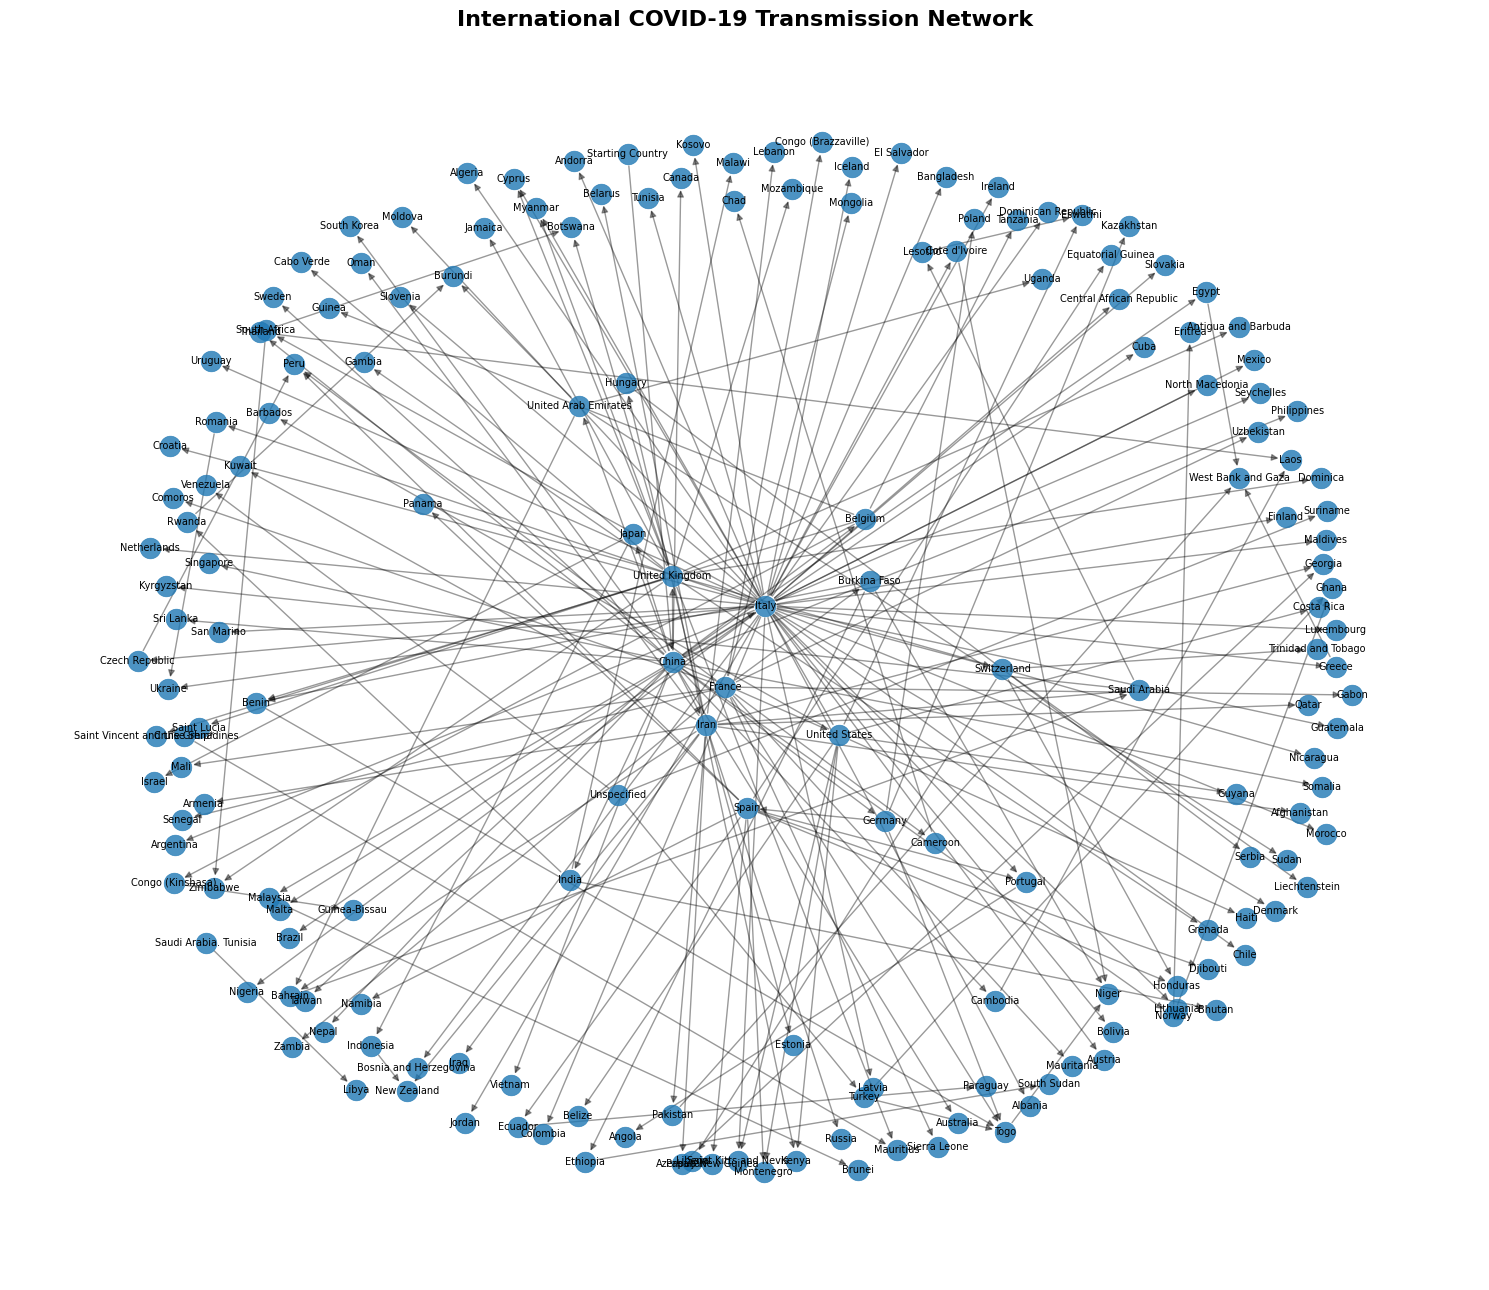

In [11]:
plt.figure(figsize=(15,13))

pos = nx.spring_layout(

    G,

    seed=42,

    k=0.8

)

nx.draw_networkx_nodes(

    G,

    pos,

    node_size=220,

    alpha=0.8

)

nx.draw_networkx_edges(

    G,

    pos,

    arrows=True,

    alpha=0.4

)

nx.draw_networkx_labels(

    G,

    pos,

    font_size=7

)

plt.title(

    "International COVID-19 Transmission Network",

    fontsize=16,

    weight="bold"

)

plt.axis("off")

plt.tight_layout()

plt.savefig(

    os.path.join(

        figures_folder,

        "TransmissionNetwork.pdf"

    ),

    dpi=300

)

plt.savefig(

    os.path.join(

        figures_folder,

        "TransmissionNetwork.png"

    ),

    dpi=300

)

plt.show()

In [12]:
print("="*60)

print("NOTEBOOK 3 - PART 1 COMPLETED")

print("="*60)

print("Network Built Successfully")

print("Nodes :", G.number_of_nodes())

print("Edges :", G.number_of_edges())

print()

print("Output Folder")

print(output_folder)

NOTEBOOK 3 - PART 1 COMPLETED
Network Built Successfully
Nodes : 178
Edges : 202

Output Folder
/content/drive/MyDrive/COVID/AdvancedNetwork


In [13]:
degree = nx.degree_centrality(G)

degree_df = pd.DataFrame({
    "Country": list(degree.keys()),
    "Degree_Centrality": list(degree.values())
})

degree_df = degree_df.sort_values(
    by="Degree_Centrality",
    ascending=False
)

display(degree_df.head(20))

degree_df.to_csv(
    os.path.join(
        tables_folder,
        "DegreeCentrality.csv"
    ),
    index=False
)

,Country,Degree_Centrality
19,Italy,0.288136
1,China,0.146893
23,Iran,0.101695
20,United Kingdom,0.090395
65,France,0.079096
22,Spain,0.062147
6,United States,0.062147
14,Germany,0.028249
37,Switzerland,0.028249
16,United Arab Emirates,0.028249


In [14]:
betweenness = nx.betweenness_centrality(
    G,
    normalized=True,
    weight=None
)

betweenness_df = pd.DataFrame({
    "Country": list(betweenness.keys()),
    "Betweenness_Centrality": list(betweenness.values())
})

betweenness_df = betweenness_df.sort_values(
    by="Betweenness_Centrality",
    ascending=False
)

display(betweenness_df.head(20))

betweenness_df.to_csv(
    os.path.join(
        tables_folder,
        "BetweennessCentrality.csv"
    ),
    index=False
)

,Country,Betweenness_Centrality
1,China,0.004911
19,Italy,0.003499
23,Iran,0.001252
22,Spain,0.000995
14,Germany,0.000867
20,United Kingdom,0.000835
6,United States,0.000546
67,Saudi Arabia,0.000417
37,Switzerland,0.000353
25,Belgium,0.000321


In [15]:
closeness = nx.closeness_centrality(G)

closeness_df = pd.DataFrame({
    "Country": list(closeness.keys()),
    "Closeness_Centrality": list(closeness.values())
})

closeness_df = closeness_df.sort_values(
    by="Closeness_Centrality",
    ascending=False
)

display(closeness_df.head(20))

closeness_df.to_csv(
    os.path.join(
        tables_folder,
        "ClosenessCentrality.csv"
    ),
    index=False
)

,Country,Closeness_Centrality
153,Niger,0.031291
85,Togo,0.030508
81,West Bank and Gaza,0.023070
92,Peru,0.019774
136,Eswatini,0.019031
84,Benin,0.015694
54,New Zealand,0.015694
67,Saudi Arabia,0.015694
142,Montenegro,0.015694
114,Ghana,0.015694


In [16]:
try:

    eigen = nx.eigenvector_centrality(
        G,
        max_iter=2000,
        tol=1e-06
    )

    eigen_df = pd.DataFrame({
        "Country": list(eigen.keys()),
        "Eigenvector_Centrality": list(eigen.values())
    })

    eigen_df = eigen_df.sort_values(
        by="Eigenvector_Centrality",
        ascending=False
    )

    display(eigen_df.head(20))

    eigen_df.to_csv(
        os.path.join(
            tables_folder,
            "EigenvectorCentrality.csv"
        ),
        index=False
    )

except Exception as e:

    print("Eigenvector Centrality could not be computed.")

    print(e)

,Country,Eigenvector_Centrality
136,Eswatini,0.999639
137,Lesotho,0.015477
147,Kyrgyzstan,0.015477
153,Niger,0.007987
158,Angola,0.007788
94,Paraguay,0.007689
146,Nicaragua,0.007689
81,West Bank and Gaza,0.000199
67,Saudi Arabia,0.000199
92,Peru,0.000198


In [17]:
pagerank = nx.pagerank(
    G,
    alpha=0.85
)

pagerank_df = pd.DataFrame({
    "Country": list(pagerank.keys()),
    "PageRank": list(pagerank.values())
})

pagerank_df = pagerank_df.sort_values(
    by="PageRank",
    ascending=False
)

display(pagerank_df.head(20))

pagerank_df.to_csv(
    os.path.join(
        tables_folder,
        "PageRank.csv"
    ),
    index=False
)

,Country,PageRank
153,Niger,0.021534
81,West Bank and Gaza,0.016350
85,Togo,0.013965
136,Eswatini,0.012111
168,Laos,0.010510
174,Burundi,0.010406
54,New Zealand,0.010206
67,Saudi Arabia,0.009551
176,South Sudan,0.009396
170,Guinea-Bissau,0.009112


In [18]:
centrality_df = degree_df.merge(
    betweenness_df,
    on="Country"
)

centrality_df = centrality_df.merge(
    closeness_df,
    on="Country"
)

if "eigen_df" in locals():

    centrality_df = centrality_df.merge(
        eigen_df,
        on="Country",
        how="left"
    )

centrality_df = centrality_df.merge(
    pagerank_df,
    on="Country"
)

display(centrality_df.head(20))

centrality_df.to_csv(
    os.path.join(
        tables_folder,
        "AllCentralityMeasures.csv"
    ),
    index=False
)

,Country,Degree_Centrality,Betweenness_Centrality,Closeness_Centrality,Eigenvector_Centrality,PageRank
0,Italy,0.288136,0.003499,0.007533,7.836538e-09,0.004743
1,China,0.146893,0.004911,0.005650,4.008407e-11,0.008256
2,Iran,0.101695,0.001252,0.007533,7.836538e-09,0.004743
3,United Kingdom,0.090395,0.000835,0.007533,7.836538e-09,0.004743
4,France,0.079096,0.000000,0.000000,1.022553e-13,0.004462
5,Spain,0.062147,0.000995,0.008475,1.018777e-06,0.005470
6,United States,0.062147,0.000546,0.007533,7.836538e-09,0.004743
7,Germany,0.028249,0.000867,0.007533,7.836538e-09,0.004743
8,Switzerland,0.028249,0.000353,0.008475,1.018777e-06,0.004543
9,United Arab Emirates,0.028249,0.000225,0.007533,7.836538e-09,0.004743


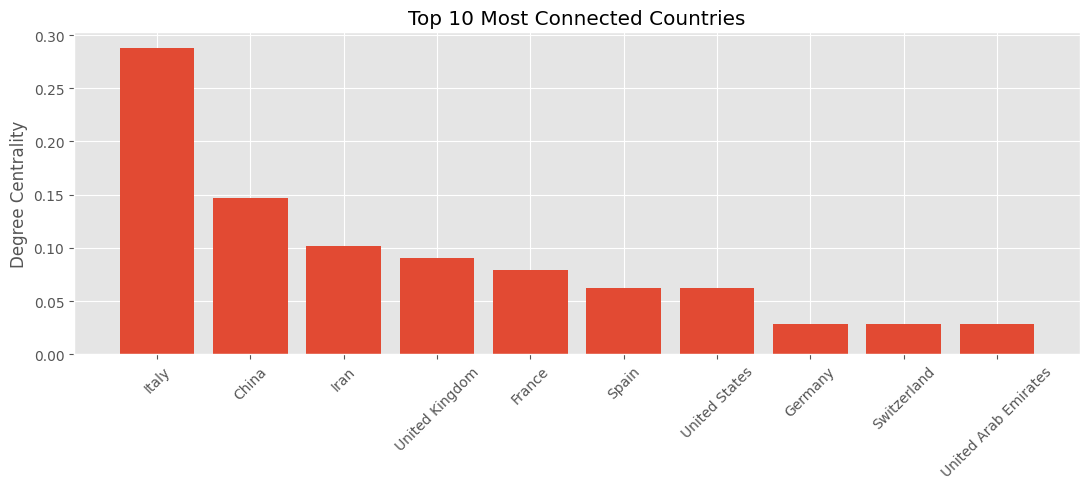

In [19]:
top = degree_df.head(10)

plt.figure(figsize=(11,5))

plt.bar(
    top["Country"],
    top["Degree_Centrality"]
)

plt.xticks(rotation=45)

plt.ylabel("Degree Centrality")

plt.title("Top 10 Most Connected Countries")

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_folder,
        "Top10DegreeCentrality.pdf"
    ),
    dpi=300
)

plt.savefig(
    os.path.join(
        figures_folder,
        "Top10DegreeCentrality.png"
    ),
    dpi=300
)

plt.show()

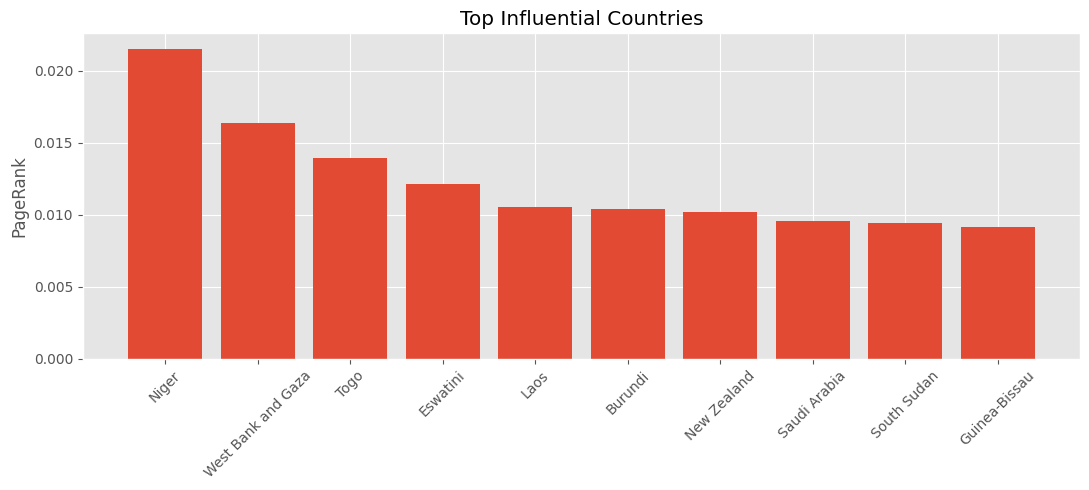

In [20]:
top = pagerank_df.head(10)

plt.figure(figsize=(11,5))

plt.bar(
    top["Country"],
    top["PageRank"]
)

plt.xticks(rotation=45)

plt.ylabel("PageRank")

plt.title("Top Influential Countries")

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_folder,
        "TopInfluentialCountries.pdf"
    ),
    dpi=300
)

plt.savefig(
    os.path.join(
        figures_folder,
        "TopInfluentialCountries.png"
    ),
    dpi=300
)

plt.show()

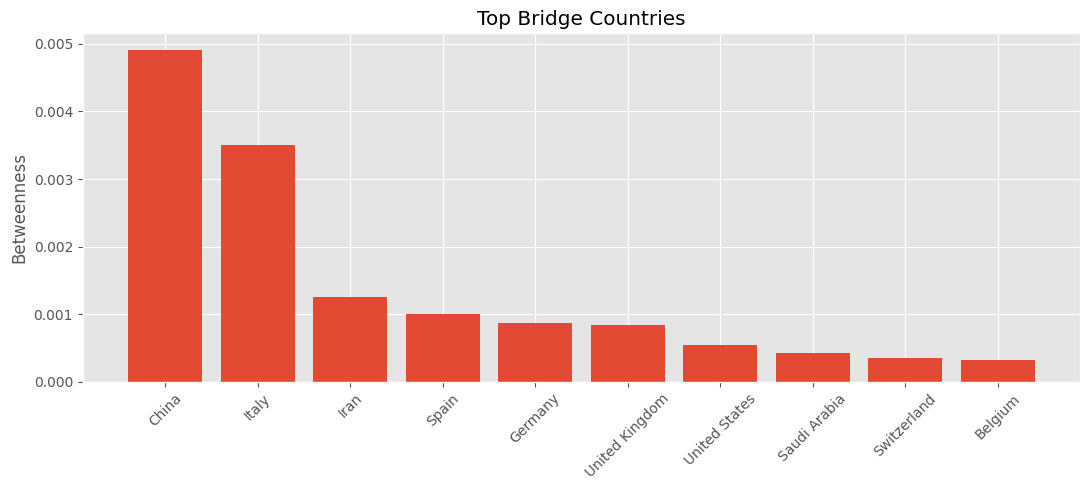

In [21]:
top = betweenness_df.head(10)

plt.figure(figsize=(11,5))

plt.bar(
    top["Country"],
    top["Betweenness_Centrality"]
)

plt.xticks(rotation=45)

plt.ylabel("Betweenness")

plt.title("Top Bridge Countries")

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_folder,
        "TopBridgeCountries.pdf"
    ),
    dpi=300
)

plt.savefig(
    os.path.join(
        figures_folder,
        "TopBridgeCountries.png"
    ),
    dpi=300
)

plt.show()

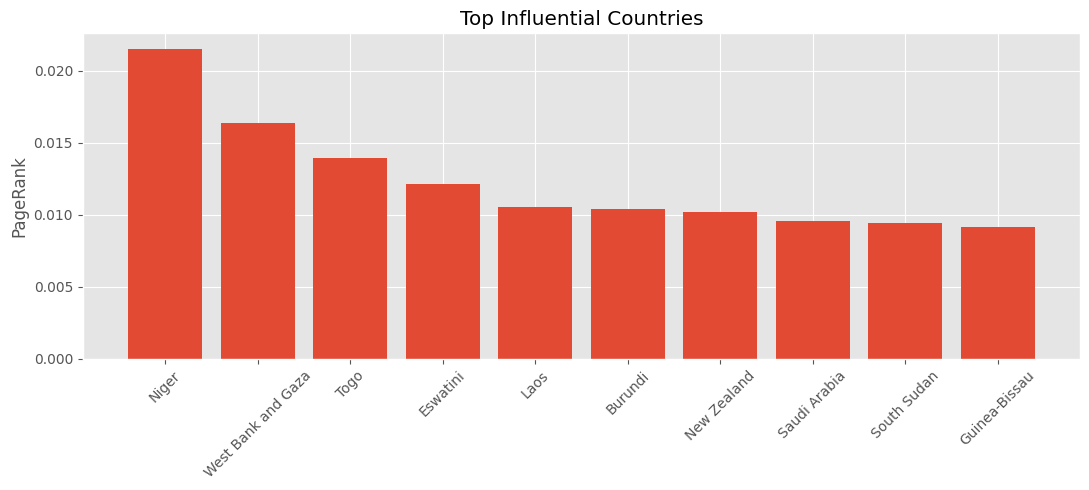

In [22]:
top = pagerank_df.head(10)

plt.figure(figsize=(11,5))

plt.bar(
    top["Country"],
    top["PageRank"]
)

plt.xticks(rotation=45)

plt.ylabel("PageRank")

plt.title("Top Influential Countries")

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_folder,
        "TopInfluentialCountries.pdf"
    ),
    dpi=300
)

plt.savefig(
    os.path.join(
        figures_folder,
        "TopInfluentialCountries.png"
    ),
    dpi=300
)

plt.show()

In [23]:
numeric_cols = centrality_df.select_dtypes(include=["number"])

corr = numeric_cols.corr()

print(corr)

corr.to_csv(
    os.path.join(
        tables_folder,
        "CentralityCorrelation.csv"
    )
)

                        Degree_Centrality  Betweenness_Centrality  \
Degree_Centrality                1.000000                0.858100   
Betweenness_Centrality           0.858100                1.000000   
Closeness_Centrality            -0.032353               -0.063471   
Eigenvector_Centrality          -0.005095               -0.015495   
PageRank                         0.040438                0.045827   

                        Closeness_Centrality  Eigenvector_Centrality  PageRank  
Degree_Centrality                  -0.032353               -0.005095  0.040438  
Betweenness_Centrality             -0.063471               -0.015495  0.045827  
Closeness_Centrality                1.000000                0.201378  0.759460  
Eigenvector_Centrality              0.201378                1.000000  0.233414  
PageRank                            0.759460                0.233414  1.000000  


In [24]:
print("="*60)
print("ADVANCED NETWORK ANALYSIS SUMMARY")
print("="*60)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print("\nTop 5 Degree Centrality")
display(degree_df.head())

print("\nTop 5 Betweenness")
display(betweenness_df.head())

print("\nTop 5 PageRank")
display(pagerank_df.head())

ADVANCED NETWORK ANALYSIS SUMMARY
Nodes: 178
Edges: 202

Top 5 Degree Centrality


,Country,Degree_Centrality
19,Italy,0.288136
1,China,0.146893
23,Iran,0.101695
20,United Kingdom,0.090395
65,France,0.079096



Top 5 Betweenness


,Country,Betweenness_Centrality
1,China,0.004911
19,Italy,0.003499
23,Iran,0.001252
22,Spain,0.000995
14,Germany,0.000867



Top 5 PageRank


,Country,PageRank
153,Niger,0.021534
81,West Bank and Gaza,0.016350
85,Togo,0.013965
136,Eswatini,0.012111
168,Laos,0.010510
